In [1]:
# Importing Data:
from google.colab import files
uploaded = files.upload()

Saving train_NYC_inspection.parquet to train_NYC_inspection.parquet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# loading parquet training dataset
df = pd.read_parquet("train_NYC_inspection.parquet")

df.head()

,CUISINE DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,INSPECTION DATE,BUILDING,STREET,SCORE,GRADE
0,Chinese,Queens,11354.0,40.759778,-73.829235,2024-08-05,136-20,ROOSEVELT AVENUE,9.0,A
1,Coffee/Tea,Queens,11362.0,40.769834,-73.736180,2025-10-31,25201,NORTHERN BLVD,9.0,A
2,Japanese,Manhattan,10036.0,40.759161,-73.990369,2025-05-02,354,WEST 44 STREET,14.0,B
3,Pizza,Queens,11372.0,40.756245,-73.878681,2025-04-15,8906,NORTHERN BLVD,40.0,C
4,Chicken,Queens,11432.0,40.708211,-73.803110,2024-02-29,87-44,PARSONS BOULEVARD,20.0,None


In [3]:
np.random.seed(42)

In [4]:
# data cleaning

# drop rows with missing target values
df = df.dropna(subset=["SCORE"])

# define features and target
target_col = "SCORE"
y = df[target_col].astype(float)

# drop non-essential columns for feature engineering
X = df.drop(columns=[target_col, "GRADE", "INSPECTION DATE", "BUILDING", "STREET"])

# encode categorical features
cuisine_encoder = LabelEncoder()
X["CUISINE_ENCODED"] = cuisine_encoder.fit_transform(X["CUISINE DESCRIPTION"])
X = X.drop(columns=["CUISINE DESCRIPTION"])

boro_encoder = LabelEncoder()
X["BORO_ENCODED"] = boro_encoder.fit_transform(X["BORO"])
X = X.drop(columns=["BORO"])

# keep only numeric features
X = X.select_dtypes(include=[np.number])

# replace missing values with median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# remove rows where target has missing values
valid_idx = y.notna()
X = X[valid_idx].values.astype(np.float64)
y = y[valid_idx].values.astype(np.float64)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features: {X.shape}")
print(f"Samples: {X.shape}")

Feature matrix shape: (127900, 5)
Target shape: (127900,)
Features: (127900, 5)
Samples: (127900, 5)


In [ ]:
# hyperparameter tuning for random forest

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

# setup cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# initialize random forest base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# perform GridSearchCV
print("\nPerforming GridSearchCV for Random Forest...")
print(f"Total parameter combinations: {2 * 3 * 2 * 2 * 2} = 144")
print("Cross-validation: 5-Fold KFold\n")

rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X, y)

print("BEST RANDOM FOREST MODEL:\n")
print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"Best CV MSE: {-rf_grid_search.best_score_:.4f}")
print(f"Best CV RMSE: {np.sqrt(-rf_grid_search.best_score_):.4f}")

# evaluate on training set
rf_train_pred = rf_grid_search.predict(X)
rf_train_r2 = r2_score(y, rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y, rf_train_pred))
rf_train_mae = mean_absolute_error(y, rf_train_pred)
rf_train_mse = mean_squared_error(y, rf_train_pred)

print(f"\nTraining Set Performance:")
print(f"  R²: {rf_train_r2:.4f}")
print(f"  RMSE: {rf_train_rmse:.4f}")
print(f"  MAE: {rf_train_mae:.4f}")
print(f"  MSE: {rf_train_mse:.4f}")

# store best scores
best_rf_rmse = np.sqrt(-rf_grid_search.best_score_)
best_rf_params = rf_grid_search.best_params_


Performing GridSearchCV for Random Forest...
Total parameter combinations: 48 = 144
Cross-validation: 5-Fold KFold

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [7]:
# gradient boosting hyperparameter tuning

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'subsample': [0.8, 1.0]
}

# initialize gradient boosting base model
gb_base = GradientBoostingRegressor(random_state=42)

# perform GridSearchCV
print("\nPerforming GridSearchCV for Gradient Boosting...")
print(f"Total parameter combinations: {2 * 3 * 3 * 2 * 2 * 2} = 144")
print("Cross-validation: 5-Fold KFold\n")

gb_grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=gb_param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

gb_grid_search.fit(X, y)

print("BEST GRADIENT BOOSTING MODEL:\n")
print(f"Best Parameters: {gb_grid_search.best_params_}")
print(f"Best CV MSE: {-gb_grid_search.best_score_:.4f}")
print(f"Best CV RMSE: {np.sqrt(-gb_grid_search.best_score_):.4f}")

# evaluate on training set
gb_train_pred = gb_grid_search.predict(X)
gb_train_r2 = r2_score(y, gb_train_pred)
gb_train_rmse = np.sqrt(mean_squared_error(y, gb_train_pred))
gb_train_mae = mean_absolute_error(y, gb_train_pred)
gb_train_mse = mean_squared_error(y, gb_train_pred)

print(f"\nTraining Set Performance:")
print(f"  R²: {gb_train_r2:.4f}")
print(f"  RMSE: {gb_train_rmse:.4f}")
print(f"  MAE: {gb_train_mae:.4f}")
print(f"  MSE: {gb_train_mse:.4f}")

# store best scores
best_gb_rmse = np.sqrt(-gb_grid_search.best_score_)
best_gb_params = gb_grid_search.best_params_


Performing GridSearchCV for Gradient Boosting...
Total parameter combinations: 144 = 144
Cross-validation: 5-Fold KFold

Fitting 5 folds for each of 144 candidates, totalling 720 fits
BEST GRADIENT BOOSTING MODEL:

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV MSE: 284.2613
Best CV RMSE: 16.8601

Training Set Performance:
  R²: 0.3243
  RMSE: 16.3230
  MAE: 12.3654
  MSE: 266.4387


In [8]:
# comparing models

comparison_data = {
    'Model': ['Random Forest', 'Gradient Boosting'],
    'CV RMSE': [best_rf_rmse, best_gb_rmse],
    'CV MSE': [-rf_grid_search.best_score_, -gb_grid_search.best_score_],
    'Training R²': [rf_train_r2, gb_train_r2],
    'Training RMSE': [rf_train_rmse, gb_train_rmse],
    'Training MAE': [rf_train_mae, gb_train_mae]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# determine best ensemble model
if best_rf_rmse < best_gb_rmse:
    best_ensemble_name = "Random Forest"
    best_ensemble_rmse = best_rf_rmse
    best_ensemble_r2 = rf_train_r2
else:
    best_ensemble_name = "Gradient Boosting"
    best_ensemble_rmse = best_gb_rmse
    best_ensemble_r2 = gb_train_r2

print(f"BEST ENSEMBLE MODEL: {best_ensemble_name}:\n")
print(f"CV RMSE: {best_ensemble_rmse:.4f}")


            Model   CV RMSE     CV MSE  Training R²  Training RMSE  Training MAE
    Random Forest 14.719116 216.652375      0.53775      13.501213      9.818069
Gradient Boosting 16.860050 284.261290      0.32434      16.322951     12.365360
BEST ENSEMBLE MODEL: Random Forest:

CV RMSE: 14.7191


In [9]:
# random forest feature importance
rf_importances = rf_grid_search.best_estimator_.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature_Index': range(len(rf_importances)),
    'Importance': rf_importances,
    'Model': 'Random Forest'
}).sort_values('Importance', ascending=False)

# gradient boosting feature importance
gb_importances = gb_grid_search.best_estimator_.feature_importances_
gb_importance_df = pd.DataFrame({
    'Feature_Index': range(len(gb_importances)),
    'Importance': gb_importances,
    'Model': 'Gradient Boosting'
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features - Random Forest:")
print(rf_importance_df.head(10).to_string(index=False))

print("\n\nTop 10 Features - Gradient Boosting:")
print(gb_importance_df.head(10).to_string(index=False))


Top 10 Features - Random Forest:
 Feature_Index  Importance         Model
             1    0.364712 Random Forest
             2    0.360064 Random Forest
             3    0.178363 Random Forest
             0    0.089230 Random Forest
             4    0.007632 Random Forest


Top 10 Features - Gradient Boosting:
 Feature_Index  Importance             Model
             1    0.362988 Gradient Boosting
             2    0.340875 Gradient Boosting
             3    0.210507 Gradient Boosting
             0    0.077647 Gradient Boosting
             4    0.007983 Gradient Boosting


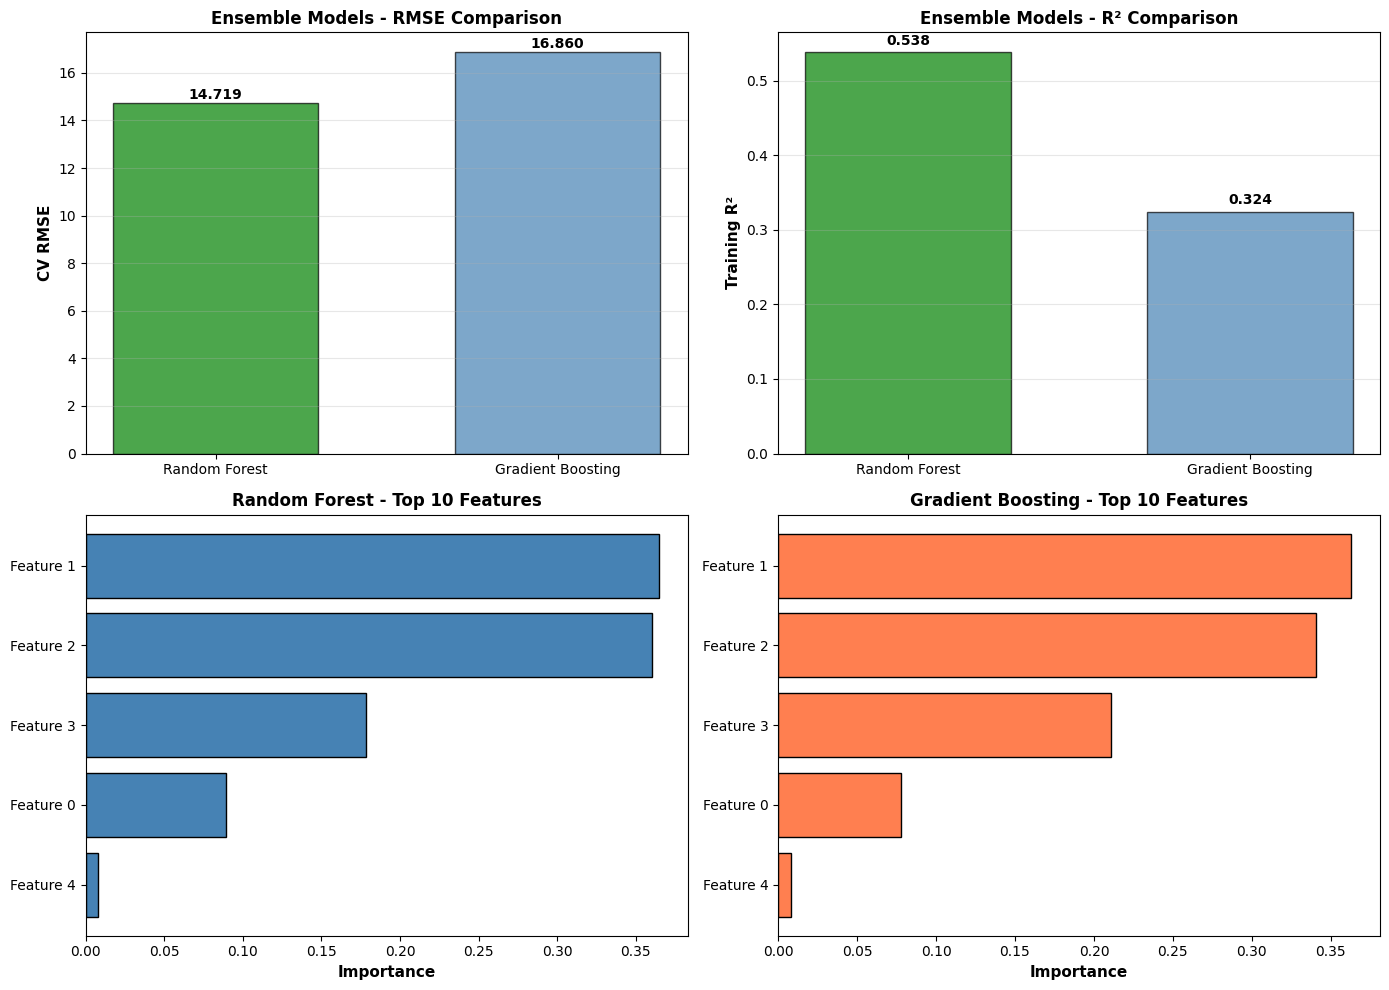

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RMSE comparison
ax1 = axes[0, 0]
models = ['Random Forest', 'Gradient Boosting']
rmse_scores = [best_rf_rmse, best_gb_rmse]
colors = ['green' if score == min(rmse_scores) else 'steelblue' for score in rmse_scores]
ax1.bar(models, rmse_scores, color=colors, alpha=0.7, edgecolor='black', width=0.6)
ax1.set_ylabel('CV RMSE', fontsize=11, fontweight='bold')
ax1.set_title('Ensemble Models - RMSE Comparison', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (model, score) in enumerate(zip(models, rmse_scores)):
    ax1.text(i, score + 0.2, f'{score:.3f}', ha='center', fontweight='bold')

# R² comparison
ax2 = axes[0, 1]
r2_scores = [rf_train_r2, gb_train_r2]
colors = ['green' if score == max(r2_scores) else 'steelblue' for score in r2_scores]
ax2.bar(models, r2_scores, color=colors, alpha=0.7, edgecolor='black', width=0.6)
ax2.set_ylabel('Training R²', fontsize=11, fontweight='bold')
ax2.set_title('Ensemble Models - R² Comparison', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, (model, score) in enumerate(zip(models, r2_scores)):
    ax2.text(i, score + 0.01, f'{score:.3f}', ha='center', fontweight='bold')

# feature importance (random forest)
ax3 = axes[1, 0]
top_rf = rf_importance_df.head(10)
ax3.barh(range(len(top_rf)), top_rf['Importance'].values, color='steelblue', edgecolor='black')
ax3.set_yticks(range(len(top_rf)))
ax3.set_yticklabels([f"Feature {idx}" for idx in top_rf['Feature_Index'].values])
ax3.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax3.set_title('Random Forest - Top 10 Features', fontsize=12, fontweight='bold')
ax3.invert_yaxis()

# feature importance (gradient boosting)
ax4 = axes[1, 1]
top_gb = gb_importance_df.head(10)
ax4.barh(range(len(top_gb)), top_gb['Importance'].values, color='coral', edgecolor='black')
ax4.set_yticks(range(len(top_gb)))
ax4.set_yticklabels([f"Feature {idx}" for idx in top_gb['Feature_Index'].values])
ax4.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax4.set_title('Gradient Boosting - Top 10 Features', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

In [11]:
# train best Random Forest on full training set
print("\nTraining best Random Forest model on full training set:")
final_rf_model = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
final_rf_model.fit(X, y)
print("Random Forest training completed")

# train best Gradient Boosting on full training set
print("Training best Gradient Boosting model on full training set:")
final_gb_model = GradientBoostingRegressor(**best_gb_params, random_state=42)
final_gb_model.fit(X, y)
print("Gradient Boosting training completed")


Training best Random Forest model on full training set:
Random Forest training completed
Training best Gradient Boosting model on full training set:
Gradient Boosting training completed


In [12]:
print("RANDOM FOREST:\n")
print(f"Best Parameters:")
for param, value in best_rf_params.items():
    print(f"  {param}: {value}")
print(f"\nCross-Validated Performance:")
print(f"RMSE: {best_rf_rmse:.4f}")
print(f"Training R²: {rf_train_r2:.4f}")
print(f"Training MAE: {rf_train_mae:.4f}")
print("\n")

print("GRADIENT BOOSTING:\n")
print(f"Best Parameters:")
for param, value in best_gb_params.items():
    print(f"  {param}: {value}")
print(f"\nCross-Validated Performance:")
print(f"RMSE: {best_gb_rmse:.4f}")
print(f"Training R²: {gb_train_r2:.4f}")
print(f"Training MAE: {gb_train_mae:.4f}")

RANDOM FOREST:

Best Parameters:
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 100

Cross-Validated Performance:
RMSE: 14.7191
Training R²: 0.5378
Training MAE: 9.8181


GRADIENT BOOSTING:

Best Parameters:
  learning_rate: 0.1
  max_depth: 7
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 200
  subsample: 0.8

Cross-Validated Performance:
RMSE: 16.8601
Training R²: 0.3243
Training MAE: 12.3654
